# Unsupervised Learning

Agenda:
1. Clustering and K-means clustering
2. Dimensionality reduction and PCA


# ![Machine Learning Map](ml_map.svg)


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
import warnings
warnings.filterwarnings('ignore')


In [2]:
def make_plot(df, centroids=None, hue=None, palette='Set2'):
    centroids = [] if centroids is None else centroids

    scatterplot_kwargs = {
        'data': df,
        'x': 'petal_length',
        'y': 'petal_width',
    }
    if hue is not None:
        scatterplot_kwargs['hue'] = hue
        scatterplot_kwargs['palette'] = palette

    ax = sns.scatterplot(**scatterplot_kwargs)

    centroid_colors = sns.color_palette(palette, n_colors=len(centroids))
    for idx, centroid in enumerate(centroids):
        ax.scatter(
            centroid[0],
            centroid[1],
            color=centroid_colors[idx],
            marker='X',
            s=100,
            label=f'Centroid {idx + 1}',
        )

    ax.set_xlabel('petal_length')
    ax.set_ylabel('petal_width')

    return ax


## The Data

We will use the classic iris dataset. Each observation is one flower. The features are four measurements, all in centimeters:
- `sepal_length`
- `sepal_width`
- `petal_length`
- `petal_width`

Sepals are the outer leaf-like parts of the flower, while petals are the inner colored parts.


In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=[name.replace(' (cm)', '').replace(' ', '_') for name in iris.feature_names])
df['flower'] = pd.Categorical.from_codes(iris.target, categories=iris.target_names)


In [4]:
df

,sepal_length,sepal_width,petal_length,petal_width,flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Clustering

Clustering is the task of putting observations into segments based on their features, so that observations within the same cluster are similar to each other. A classical example is grouping customers into groups based on their purchasing patterns - purchase frequency, how much they spend on average, etc.

K-means is one of the most popular clustering algorithms, and it's also very simple. For a chosen number of clusters `k`, it iteratively assigns points to the nearest centroid and updates centroids to the average of assigned points.


<Axes: xlabel='petal_length', ylabel='petal_width'>

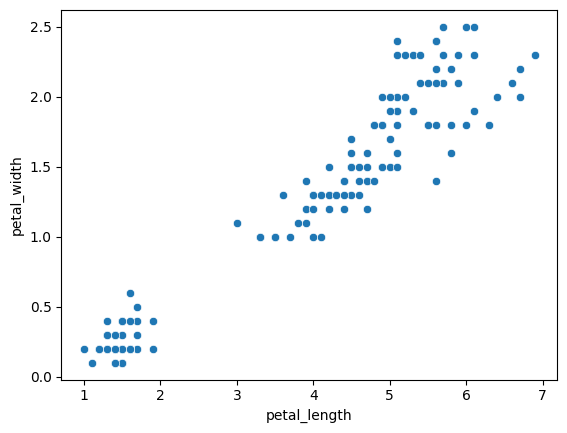

In [5]:
make_plot(df)

### Step 1

Choose cluster centroids randomly.


Centroid 1:  (np.float64(4.7), np.float64(1.2))
Centroid 2:  (np.float64(1.7), np.float64(0.3))


<Axes: xlabel='petal_length', ylabel='petal_width'>

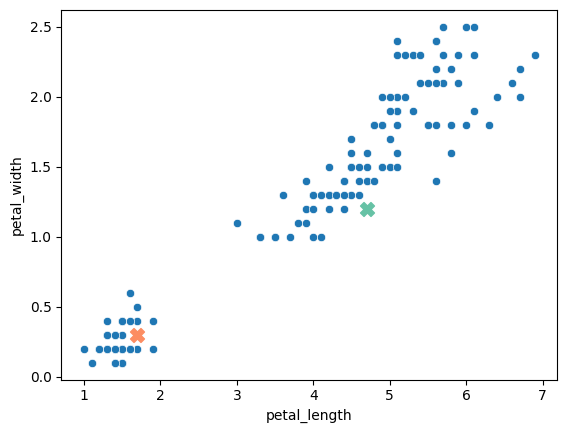

In [6]:
# Randomly select two data points from the dataset as initial centroids
random_indices = np.random.choice(len(df), 2, replace=False)
k1 = (
    df.iloc[random_indices[0]]["petal_length"],
    df.iloc[random_indices[0]]["petal_width"],
)
k2 = (
    df.iloc[random_indices[1]]["petal_length"],
    df.iloc[random_indices[1]]["petal_width"],
)
print("Centroid 1: ", k1)
print("Centroid 2: ", k2)
make_plot(df, [k1, k2])

### Step 2

Assign each point to the closest centroid.

Calculate distance to the cluster for each point:

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2}
$$

where x and y are two points.

Reminder for Euclidian distance in n dimensions:

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
$$

In [7]:
# calculate distance
df["dist_to_k1"] = np.sqrt((df['petal_length'] - k1[0]) ** 2 + (df['petal_width'] - k1[1]) ** 2)
df["dist_to_k2"] = np.sqrt((df['petal_length'] - k2[0]) ** 2 + (df['petal_width'] - k2[1]) ** 2)
df

,sepal_length,sepal_width,petal_length,petal_width,flower,dist_to_k1,dist_to_k2
0,5.1,3.5,1.4,0.2,setosa,3.448188,0.316228
1,4.9,3.0,1.4,0.2,setosa,3.448188,0.316228
2,4.7,3.2,1.3,0.2,setosa,3.544009,0.412311
3,4.6,3.1,1.5,0.2,setosa,3.352611,0.223607
4,5.0,3.6,1.4,0.2,setosa,3.448188,0.316228
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1.208305,4.031129
146,6.3,2.5,5.0,1.9,virginica,0.761577,3.667424
147,6.5,3.0,5.2,2.0,virginica,0.943398,3.891015
148,6.2,3.4,5.4,2.3,virginica,1.303840,4.205948


In [8]:
# assign point to a closer cluster
df["cluster"] = np.argmin(df[["dist_to_k1", "dist_to_k2"]], axis=1)
df

,sepal_length,sepal_width,petal_length,petal_width,flower,dist_to_k1,dist_to_k2,cluster
0,5.1,3.5,1.4,0.2,setosa,3.448188,0.316228,1
1,4.9,3.0,1.4,0.2,setosa,3.448188,0.316228,1
2,4.7,3.2,1.3,0.2,setosa,3.544009,0.412311,1
3,4.6,3.1,1.5,0.2,setosa,3.352611,0.223607,1
4,5.0,3.6,1.4,0.2,setosa,3.448188,0.316228,1
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1.208305,4.031129,0
146,6.3,2.5,5.0,1.9,virginica,0.761577,3.667424,0
147,6.5,3.0,5.2,2.0,virginica,0.943398,3.891015,0
148,6.2,3.4,5.4,2.3,virginica,1.303840,4.205948,0


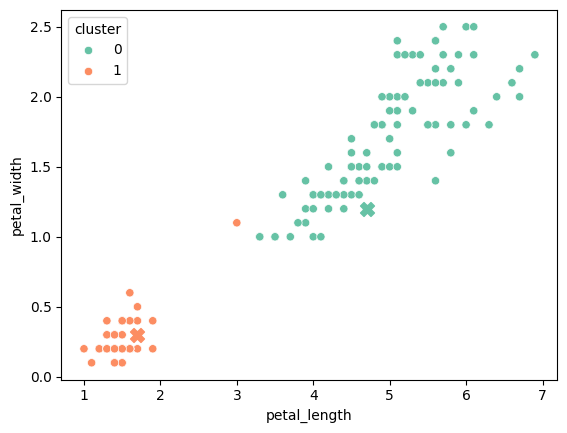

In [9]:
ax = make_plot(df, [k1, k2], hue='cluster')


### Step 3

Recalculate the new centroids as the average of the datapoints in each cluster


In [10]:
k1 = df[df['cluster'] == 0][['petal_length', 'petal_width']].mean().tolist()
k2 = df[df['cluster'] == 1][['petal_length', 'petal_width']].mean().tolist()


<Axes: xlabel='petal_length', ylabel='petal_width'>

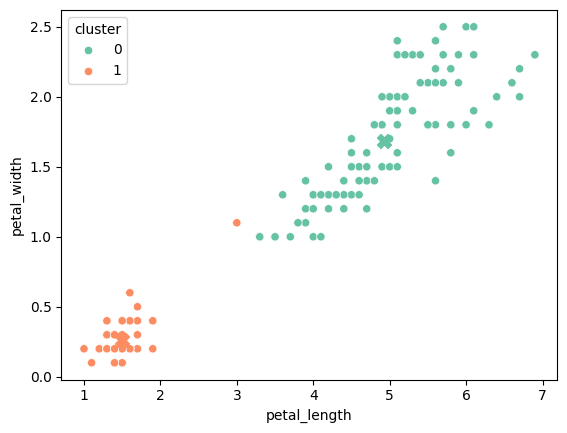

In [11]:
make_plot(df, [k1, k2], hue='cluster')

## Repeat steps 2 and 3

1. Recalculate distances between points and centroids
2. Assign each point to the closest centroid
3. Calculate new centroids

<Axes: xlabel='petal_length', ylabel='petal_width'>

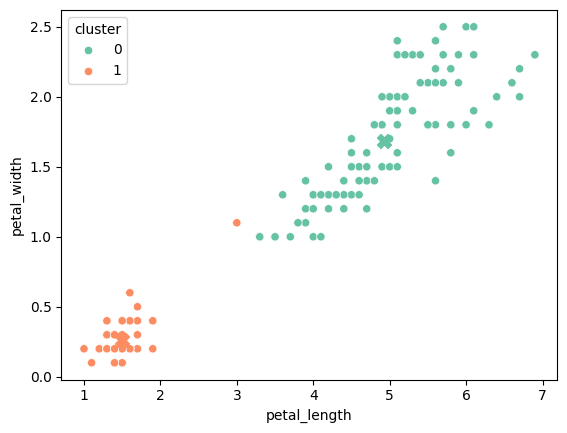

In [12]:
df["dist_to_k1"] = np.sqrt((df['petal_length'] - k1[0]) ** 2 + (df['petal_width'] - k1[1]) ** 2)
df["dist_to_k2"] = np.sqrt((df['petal_length'] - k2[0]) ** 2 + (df['petal_width'] - k2[1]) ** 2)
df["cluster"] = np.argmin(df[["dist_to_k1", "dist_to_k2"]], axis=1)

make_plot(df, [k1, k2], hue='cluster')


<Axes: xlabel='petal_length', ylabel='petal_width'>

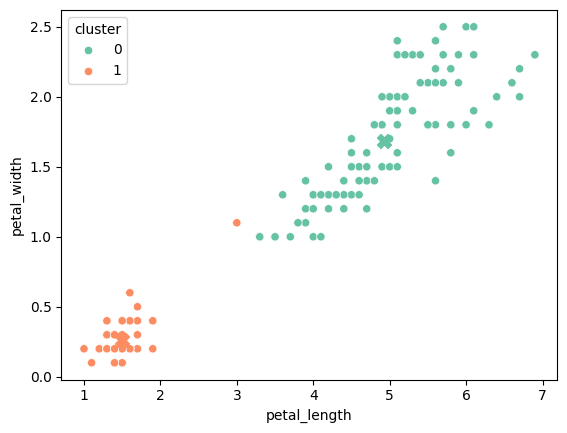

In [13]:
k1 = df[df['cluster'] == 0][['petal_length', 'petal_width']].mean().tolist()
k2 = df[df['cluster'] == 1][['petal_length', 'petal_width']].mean().tolist()

make_plot(df, [k1, k2], hue='cluster')

In practice, we repeat these steps until some stopping criterion is reached. Common stopping criteria are reaching a maximum number of iterations or centroids moving by less than a small threshold.


### K-means in scikit-learn

As always, we don't have to worry about implementing the algorithm ourselves. Scikit-learn provides us with k-means implementation that also includes some optimizations, like a more optimal way to choose the initial points.


<Axes: xlabel='petal_length', ylabel='petal_width'>

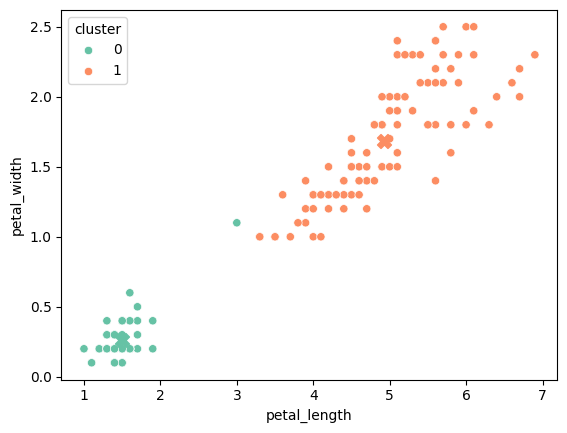

In [14]:
from sklearn.cluster import KMeans

kmeans2 = KMeans(
    n_clusters=2,
    max_iter=100, # how many updates we should do
    # tol=1e-4, # tolerance for how much the centroids have to move for the algorithm to continue
)
kmeans2.fit(df[['petal_length', 'petal_width']]) # No y (target) column!
df['cluster'] = kmeans2.labels_
k1 = kmeans2.cluster_centers_[0]
k2 = kmeans2.cluster_centers_[1]

make_plot(df, kmeans2.cluster_centers_, hue='cluster')


But what is k-means minimizing? It's minimizing the sum of within-cluster variance (sum of squares).

$$
\text{WCSS} = \sum_{k=1}^{K} \sum_{i \in C_k} \lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2
$$

For instance, what is the variance within the smaller cluster on the plot above?

In [15]:
points = df[['petal_length', 'petal_width']].values


In [16]:
# sum of squares within cluster 0
centroid = kmeans2.cluster_centers_[0]
cluster_points = points[df['cluster'] == 0]
ss0 = np.sum((cluster_points - centroid) ** 2)


In [17]:
# sum of squares within cluster 1
centroid = kmeans2.cluster_centers_[1]
cluster_points = points[df['cluster'] == 1]
ss1 = np.sum((cluster_points - centroid) ** 2)


In [18]:
# within-cluster sum of squares
ss1 + ss0

np.float64(86.39021984551397)

In [19]:
kmeans2.inertia_


86.39021984551397

Variance within the second cluster is a lot bigger, which also checks out visually. There also seems to be one point that the algorithm is placing in the wrong cluster visually.

If we were to use three centroids, the bigger cluster would get split because that would give a bigger reduction in variance.


<Axes: xlabel='petal_length', ylabel='petal_width'>

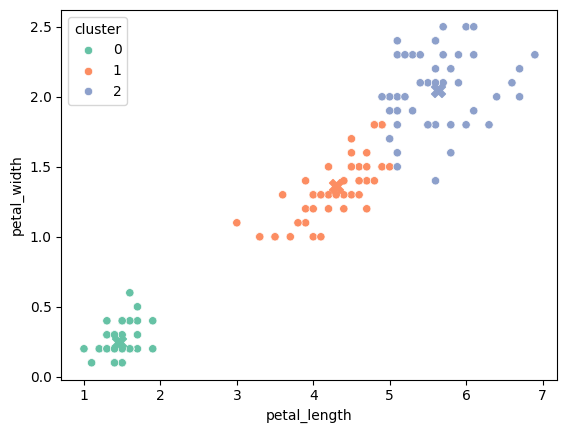

In [20]:
kmeans3 = KMeans(n_clusters=3)
kmeans3.fit(df[['petal_length', 'petal_width']])
df['cluster'] = kmeans3.labels_

make_plot(df, kmeans3.cluster_centers_, hue='cluster')

In [21]:
kmeans3.inertia_

31.412885668276978

How do we choose how many clusters to cluster into?


### Task

Fit K-means clustering for various number of clusters, save inertia for each into a list and plot the results. The end goal is to have k on the x axis, and inertia on the y axis. The range for k should be (2, 10).

What do you notice? How would you choose the optimal value for k?


<Axes: xlabel='k', ylabel='inertia'>

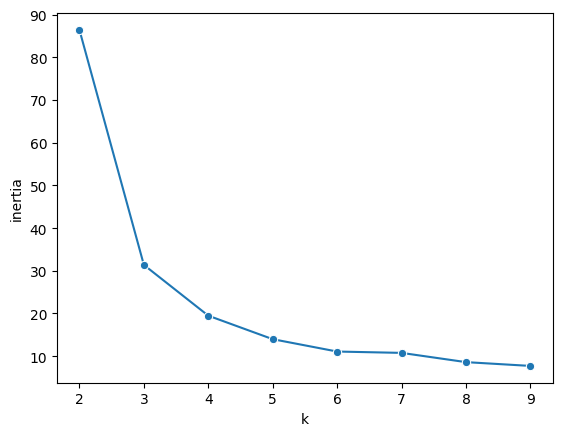

In [ ]:
# Answer
inertias = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['petal_length', 'petal_width']])
    inertias.append(kmeans.inertia_)

data = pd.DataFrame({'k': k_values, 'inertia': inertias})
sns.lineplot(x='k', y='inertia', data=elbow_data, marker='o')


Since k-means clustering is not a supervised learning algorithm, there is no obvious answer for how many clusters to choose. The variance will keep decreasing forever.

So how can we choose the optimal number for k? One method is called the elbow method - we look at the plot above and try to find values for `k`that form an elbow. On the plot above that elbow seems to be around k=3. This means that from k=2 to k=3 we saw a big decrease in inertia, but later those decreases were smaller, and thus we see the elbow.

However, this is only a heuristic. Sometimes there is no clear elbow at all, and then the choice of `k` is ambiguous and has to be guided by context, usefulness, and judgment. For example, we may already know that we want 3 customer segments, 4 product categories, or 5 store types because that is how the result will be used.


We can also check how the clusters that the algorithm discovered overlap with actual flowers.


Text(0.5, 1.0, 'Actual Iris Species')

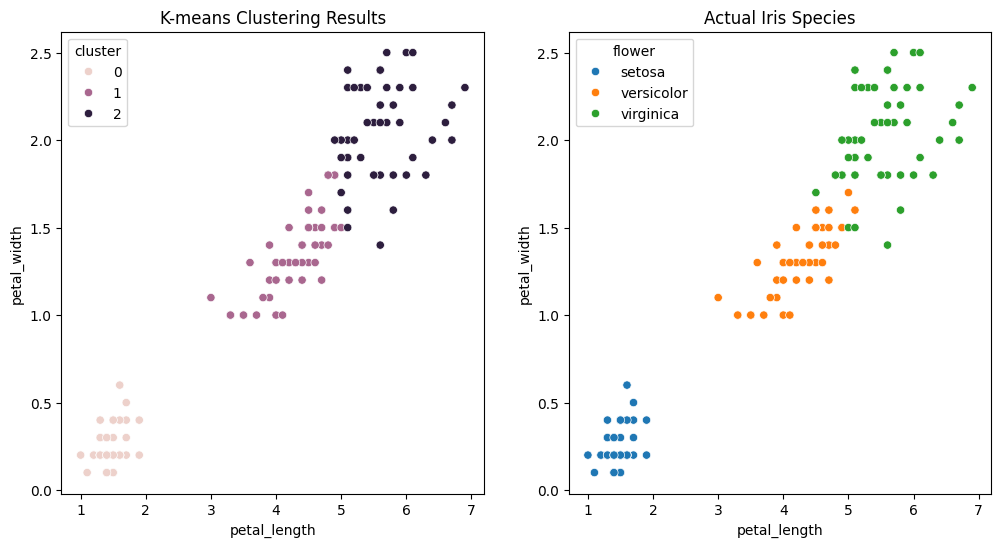

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(
    x='petal_length', 
    y='petal_width', 
    hue='cluster',
    data=df,
    ax=axs[0]
)
axs[0].set_title('K-means Clustering Results')

sns.scatterplot(
    x='petal_length', 
    y='petal_width', 
    hue='flower',
    data=df,
    ax=axs[1]
)
axs[1].set_title('Actual Iris Species')


Important to keep in mind about K-Means clustering:
- It aims to reduce within-cluster variance, but it is not guaranteed to find the globally optimal clustering.
- K-means works best when clusters are compact and reasonably well separated under Euclidean distance. If the true groups have irregular shapes, it may perform poorly.
- Results can also depend on initialization and on feature scaling, so in many datasets we should standardize features before applying the method.
- The final choice of clusters should be judged not only by plots or inertia, but also by whether the segmentation is useful in the real context of the problem.
- K-means does not work well when there are many features in the dataset - we need to compress those features.


## Dimensionality Reduction

Dimensionality reduction is a family of methods for replacing a larger set of features with a smaller set that still captures much of the useful structure in the data.

- It helps with **visualization** because we can reduce many features to 2 or 3 dimensions and then plot the data.
- It helps with **simplification** because we can compress the dataset into fewer features and sometimes remove noisy or redundant information.
- It helps as a **preprocessing step** before other methods, including clustering and predictive models.

Principal Component Analysis (PCA) is one of the most common dimensionality reduction methods. It finds new features, called principal components, which are linear combinations of the original features chosen to capture as much variance as possible. PCA does not simply keep some original columns and drop others: it creates a new rotated coordinate system for the data.

For one principal component, the gist is:
1. Start with the original features.
2. Find the direction in which the data varies the most.
3. Project each datapoint onto that direction.
4. Use those projected values as the new 1-dimensional feature.


In [24]:
df = df.drop(columns=["dist_to_k1", "dist_to_k2", "cluster"], errors="ignore")


We start with the original features, `petal_length` and `petal_width`.


Text(0.5, 1.0, 'Original features')

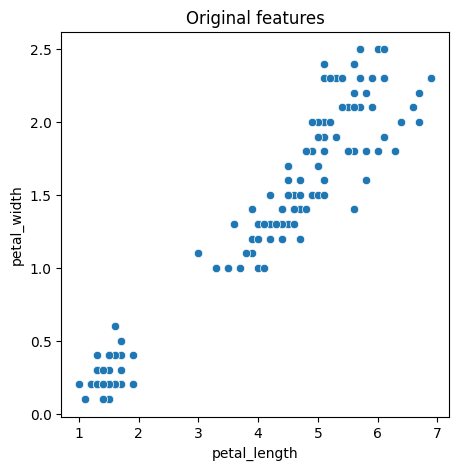

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

sns.scatterplot(x="petal_length", y="petal_width", data=df, ax=axs)
axs.set_title("Original features")


In this simple 2-feature example, PCA is trying to replace `petal_length` and `petal_width` with one new feature of the form `pc1 = w1 * petal_length + w2 * petal_width`.

The algorithm chooses the weights `w1` and `w2` automatically. Intuitively, we can imagine rotating a line through the middle of the point cloud and asking: along which line do the projected points spread out the most? PCA chooses that line.


In [26]:
from sklearn.decomposition import PCA

X = df[["petal_length", "petal_width"]]

pca = PCA(n_components=1)
pca.fit(X)
component = pca.components_[0]
component


array([0.92177769, 0.38771882])

What we get out of the PCA algorithm is a vector that points in the direction of maximum variance.


These two numbers are the weights of the linear combination. Here, the first component puts more weight on `petal_length` than on `petal_width`, so the new feature is more strongly aligned with petal length while still using both variables.

The sign itself is not important: if we multiplied the whole vector by `-1`, it would point in the opposite direction but still describe the same principal component.


In [27]:
pca.explained_variance_ratio_[0]


np.float64(0.9902506624845562)

The explained variance ratio tells us how much of the original variation is preserved when we replace two features with one principal component.

$$
\text{explained variance ratio} = \frac{\text{variance explained by the principal component}}{\text{total variance in the original data}}
$$

The unexplained part is what is left over after this. If the explained ratio is close to 1, then one principal component already summarizes the original data very well.


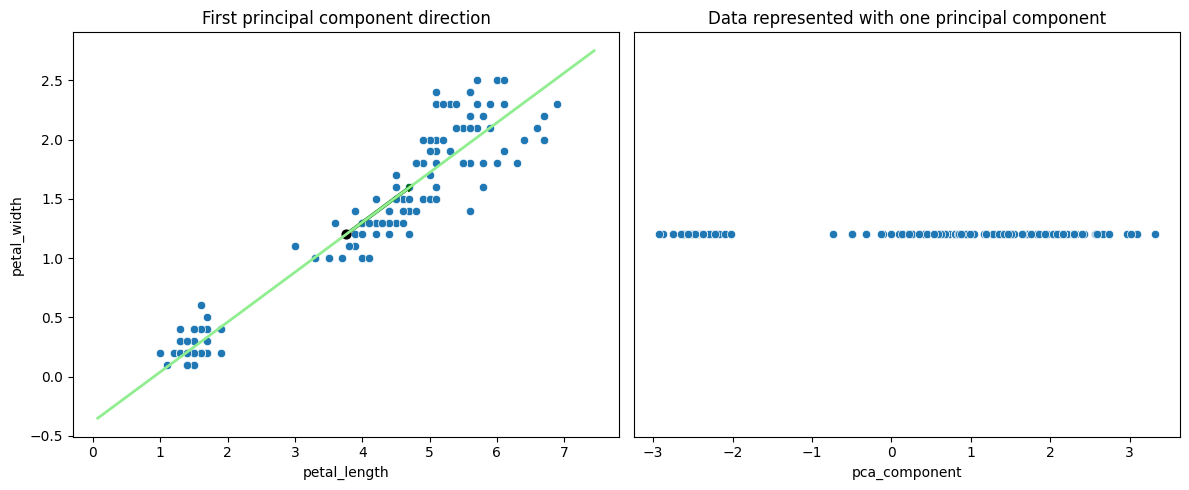

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X["petal_length"], y=X["petal_width"], ax=axs[0])

mean = pca.mean_
line_scale = 4
line_points = np.vstack([
    mean - line_scale * component,
    mean + line_scale * component,
])

axs[0].plot(line_points[:, 0], line_points[:, 1], color="lightgreen", linewidth=2)
axs[0].arrow(mean[0], mean[1], component[0], component[1], color="darkgreen", width=0.02)
axs[0].scatter(mean[0], mean[1], color="black", s=40)
axs[0].set_title("First principal component direction")

X_pca = pca.transform(X)
df["pca_component"] = X_pca.flatten()

sns.scatterplot(
    x="pca_component",
    y=np.zeros(len(df)),
    data=df,
    ax=axs[1],
)
axs[1].set_yticks([])
axs[1].set_ylabel("")
axs[1].set_title("Data represented with one principal component")

plt.tight_layout()


The green line shows the first principal component: the direction that captures the most variance in the data.

If we keep only one principal component, then each flower is represented by a single coordinate along that line. These projected values are often called PCA scores. What remains is a 1-dimensional version of the data; the unexplained part is the variation lost when we compress the two original features into one.


If we keep two components instead of one, then the first component captures the most variance in the data, and the second component captures the most remaining variance subject to being perpendicular to the first. This matters because the second component is not just another high-variance direction: it is the best high-variance direction among those that do not overlap with the first.


### Task

Try PCA on a dataset with four features with up to 3 principal components.

1. Fit PCA with `n_components` 1, 2 and 3.
2. Plot how much variance is explained in each case.
3. Based on this plot, decide how many components seem reasonable to keep.


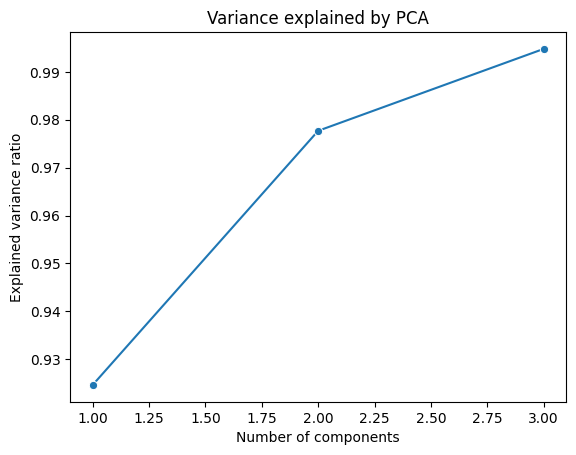

In [29]:
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

n_components_values = [1, 2, 3]
explained_variance_ratios = []

for n_components in n_components_values:
    pca = PCA(n_components=n_components)
    pca.fit(X)
    explained_variance_ratios.append(pca.explained_variance_ratio_.sum())

pd.DataFrame({
    "n_components": n_components_values,
    "explained_variance_ratio": explained_variance_ratios,
})

sns.lineplot(
    x=n_components_values,
    y=explained_variance_ratios,
    marker="o",
)
plt.xlabel("Number of components")
plt.ylabel("Explained variance ratio")
plt.title("Variance explained by PCA")
plt.show()


### Task

Using PCA, reduce the dimensions of the dataset from four features to two. Plot the new dataset on a scatterplot and indicate which point belongs to which flower.


<Axes: xlabel='component_1', ylabel='component_2'>

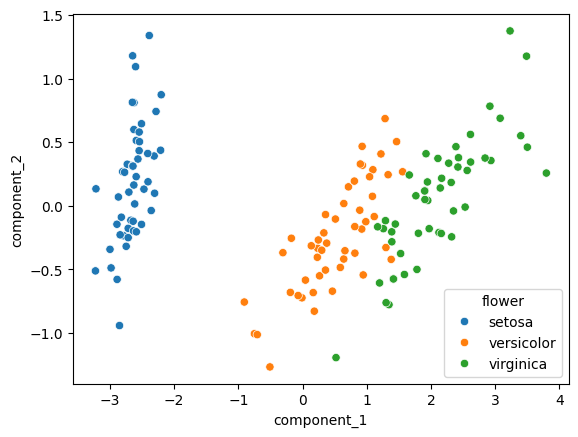

In [30]:
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)
df["component_1"] = X_pca[:, 0]
df["component_2"] = X_pca[:, 1]

sns.scatterplot(x="component_1", y="component_2", hue="flower", data=df)


In [31]:
pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["component_1", "component_2"],
)


,sepal_length,sepal_width,petal_length,petal_width
component_1,0.361387,-0.084523,0.856671,0.358289
component_2,0.656589,0.730161,-0.173373,-0.075481


### Task

Apply K-means clustering to the new features.

1. Find the optimal number of clusters using the elbow method.
2. Apply KMeans with the optimal number of clusters and vizualise the clusters on a scatterplot.


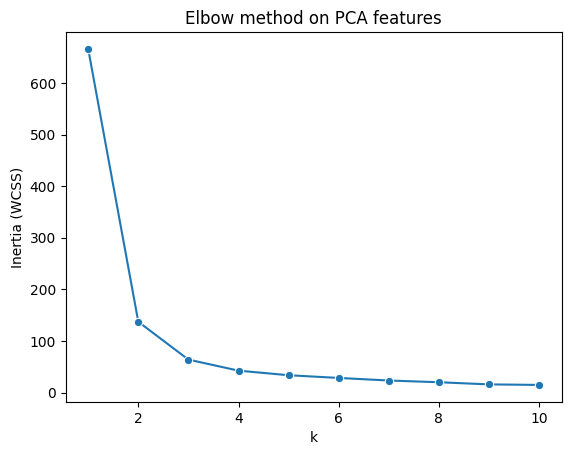

In [32]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_pca = KMeans(n_clusters=k)
    kmeans_pca.fit(df[["component_1", "component_2"]])
    inertias.append(kmeans_pca.inertia_)

pd.DataFrame({"k": k_values, "inertia": inertias})

sns.lineplot(x=list(k_values), y=inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow method on PCA features")
plt.show()


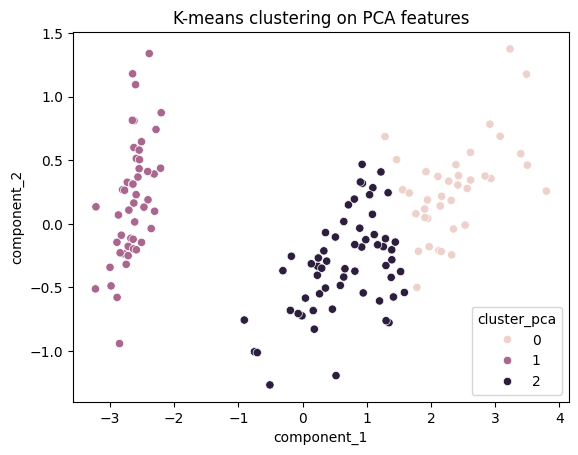

In [33]:
optimal_k = 3

kmeans_pca = KMeans(n_clusters=optimal_k)
kmeans_pca.fit(df[["component_1", "component_2"]])
df["cluster_pca"] = kmeans_pca.labels_

sns.scatterplot(
    x="component_1",
    y="component_2",
    hue="cluster_pca",
    data=df,
)
plt.title("K-means clustering on PCA features")
plt.show()


### Note on scaling

Both K-means and PCA are sensitive to feature scale. In this iris dataset the features are all measured in centimeters and are already on fairly similar scales, so scaling is not very important here. In many real datasets, however, features can be on very different scales, and then it is good practice to standardize features before applying either method.


How many principal components should we keep?
- If we want to visualize the data, we will usually choose 2 components (or sometimes 3).
- If the goal is compression or preprocessing before another model, we often choose enough components to preserve a large share of the variance.
- A common practical rule is to look at cumulative explained variance and keep enough components to explain something like 80% to 95% of the variance, depending on the problem.

PCA and clustering are also often done in the same workflow. A common pattern is to first reduce a high-dimensional dataset to a smaller number of components, and then run clustering on those components.


## Recap

- **Unsupervised learning** works without a target variable. Instead of predicting `y`, we try to find structure in the features themselves.
- **K-means clustering** groups observations by iteratively assigning points to the nearest centroid and then updating the centroids.
- The number of clusters `k` can be guided by heuristics like the elbow method, but also by business understanding and the purpose of the analysis.
- **PCA** reduces dimensionality by creating new linear combinations of the original features that preserve as much variance as possible.
- Both **K-means** and **PCA** depend on the scale of the features, so scaling often matters in practice.

## Friday

On Friday we will work with text data - we will extract embeddings of articles, and apply PCA and K-means clustering to understand the structure in the data.
